## Phase 3: SHAP explainability on the LightGBM baseline

Walks through `src/models/explain_shap.py` step by step, reusing its actual
functions rather than re-deriving the logic here, same pattern as notebooks
05-07.

Goal: turn LightGBM from "a model that scores well" (Phase 2) into
per-feature attribution that can support a plain-English business
narrative - which features actually drive the model's predictions, in
which direction, and whether that agrees with what Phase 2's raw
correlations suggested. See `docs/concepts_log.md`'s 2026-09-20 entry for
the full SHAP/TreeExplainer concept explanation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / "src"))

from models.baseline_lightgbm import fit_baseline, print_feature_importance
from models.baseline_logistic_regression import (
    BINARY_COLS,
    CONTINUOUS_COLS,
    FEATURE_COLS,
    load_train_val,
    prepare_features,
)
from models.explain_shap import (
    compute_shap_values,
    feature_direction,
    global_importance,
)

### Load train + val, fit LightGBM

Same data-loading and fitting as the Phase 2 LightGBM baseline notebook -
nothing about the model changes here, only what's done with it afterward.
SHAP is computed on val, not test: it isn't a "reported metric" the way
precision@K is, so there's no reason to spend test's one-time-only
guarantee (`docs/decisions/004-three-way-split.md`) on an exploratory
step.

In [2]:
df = load_train_val()
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]

X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(val_df)

model = fit_baseline(X_train, y_train, X_val, y_val)
print(f"fit LightGBM: best_iteration_={model.best_iteration_}, val n={len(y_val):,}")

fit LightGBM: best_iteration_=36, val n=1,751,740


### Compute SHAP values via TreeExplainer, and verify the additivity guarantee

`TreeExplainer` computes exact Shapley values for a tree ensemble by
walking the actual tree structure. The guarantee that makes this different
from a plain feature-importance number: for every single row,
`shap_values.sum(axis=1) + expected_value` reproduces that row's exact raw
(log-odds) prediction. Checked explicitly below rather than just trusted -
`compute_shap_values` already runs this check internally
(`check_additivity=True`), so this cell is confirming the same guarantee by
hand, on the real val data.

In [3]:
shap_values, expected_value = compute_shap_values(model, X_val)
print(f"expected_value (log-odds baseline, i.e. average val prediction): {expected_value:.4f}")

raw_scores = model.predict(X_val, raw_score=True)
reconstructed = shap_values.sum(axis=1) + expected_value
max_gap = np.abs(reconstructed - raw_scores).max()
print(f"max |reconstructed - actual raw score| across all {len(X_val):,} val rows: {max_gap:.2e}")

C:\Users\Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


expected_value (log-odds baseline, i.e. average val prediction): -6.7785


max |reconstructed - actual raw score| across all 1,751,740 val rows: 2.84e-13


### Global importance: SHAP vs. LightGBM's own split-count importance vs. Phase 2's raw correlation

Three different ways to ask "which feature matters," computed here side by
side on the same val data:
- **split count** - how many times a feature was used as a split point
  across all trees (what `print_feature_importance` already reports; cares
  how *often* a feature was touched, not how much it moved any prediction).
- **mean |SHAP value|** - how much a feature actually moved predictions on
  average (today's new number).
- **|correlation| with adoption** - the same linear-association measure
  Phase 2 used to rank raw features, recomputed here on val for a
  same-dataset comparison (Phase 2's number was computed on train).

In [4]:
importance = global_importance(shap_values, FEATURE_COLS)
direction = feature_direction(X_val, shap_values, FEATURE_COLS)

split_count = pd.Series(model.feature_importances_, index=FEATURE_COLS)
val_corr = pd.Series(
    {col: np.corrcoef(X_val[col], y_val)[0, 1] if X_val[col].std() > 0 else np.nan for col in FEATURE_COLS}
)

comparison = pd.DataFrame({
    "mean_abs_shap": importance,
    "shap_rank": importance.rank(ascending=False, method="min").astype("Int64"),
    "split_count": split_count.reindex(importance.index),
    "split_count_rank": split_count.rank(ascending=False, method="min").astype("Int64").reindex(importance.index),
    "abs_val_corr": val_corr.abs().reindex(importance.index),
    "corr_rank": val_corr.abs().rank(ascending=False, method="min").astype("Int64").reindex(importance.index),
}).sort_values("mean_abs_shap", ascending=False)
comparison

,mean_abs_shap,shap_rank,split_count,split_count_rank,abs_val_corr,corr_rank
activity_index,0.984062,1,56,5,0.076511,2
age_years,0.621813,2,292,1,0.031570,6
product_count_prev,0.562935,3,180,3,0.145992,1
tenure_months,0.118051,4,256,2,0.052409,4
renta_log,0.054757,5,145,4,0.020680,8
segmento_universitario,0.049953,6,16,10,0.044590,5
age_years_sq,0.046383,7,27,8,0.017815,9
segmento_particulares,0.043735,8,18,9,0.024906,7
sexo_v,0.023651,9,31,6,0.015644,10
sexo_h,0.014631,10,31,6,0.015644,11


### A real finding: the three rankings disagree on the #1 feature

- **SHAP** ranks `activity_index` highest.
- **Split count** ranks `age_years` highest (consistent with the Phase 2
  LightGBM notebook's finding - `age_years`'s non-monotonic pattern needs
  many splits to trace, which inflates split count without necessarily
  meaning each split moves predictions by much).
- **Raw correlation** ranked `product_count_prev` highest back in Phase 2
  (~0.166, the strongest of any single feature at the time).

These aren't contradictions so much as three different questions: how
*often* is a feature touched (split count), how linearly does it move with
the outcome on its own (correlation), and how much does it actually move
*this trained model's* predictions once every feature's effect is
accounted for (SHAP). `activity_index` topping SHAP suggests the model
leans on it more than a marginal, one-feature-at-a-time view would
suggest - worth featuring prominently in the Phase 3 narrative rather than
defaulting to "product count matters most" just because that was Phase 2's
headline number.

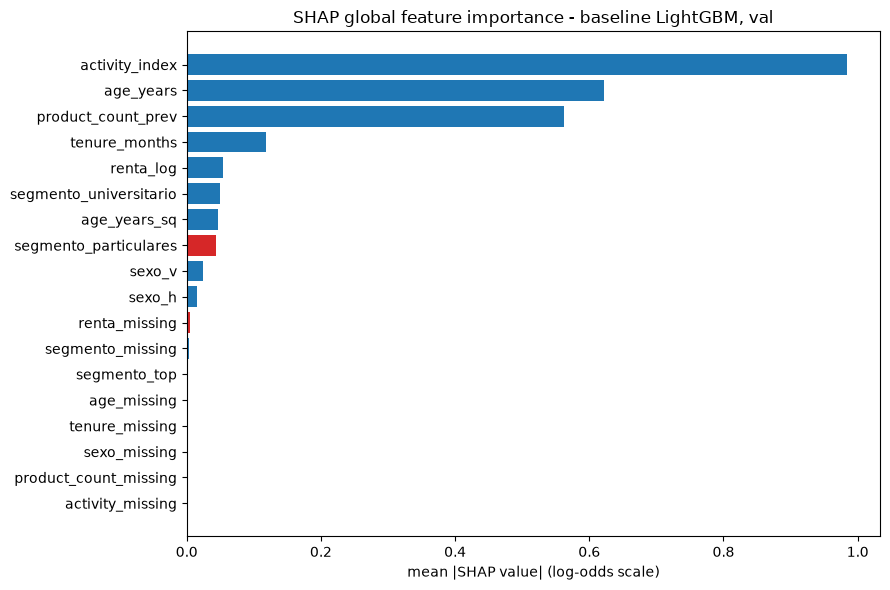

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
top = importance.sort_values()
colors = ["#d62728" if direction.reindex(top.index)[f] < 0 else "#1f77b4" for f in top.index]
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel("mean |SHAP value| (log-odds scale)")
ax.set_title("SHAP global feature importance - baseline LightGBM, val")
plt.tight_layout()
plt.show()

### Direction of effect

Correlation between each feature's raw value and its own SHAP value - a
compact stand-in for a beeswarm plot: positive means higher feature values
push predictions up (toward adoption), negative means the opposite. A
handful of `*_missing` flags come back `NaN` - they're near-constant in
val (train's ~0.16% missing rate barely shows up in val's 2-month window),
which leaves both the feature's own variance and its SHAP variance at
zero, making correlation undefined rather than meaningfully zero.

In [6]:
direction.reindex(importance.index).rename("direction_corr").to_frame()

,direction_corr
activity_index,0.958833
age_years,0.452268
product_count_prev,0.724331
tenure_months,0.661918
renta_log,0.056850
segmento_universitario,0.496546
age_years_sq,0.021092
segmento_particulares,-0.080452
sexo_v,0.734476
sexo_h,0.181943


### Explaining one real customer's prediction

The additivity guarantee's actual payoff: not just "which features matter
on average" but "why did the model score *this specific customer* this
way." Picking val's single highest-scored row and showing which features
pushed it up and which pulled it down, from the log-odds baseline
(`expected_value`) to the model's final raw score for that row.

In [7]:
val_scores = model.predict_proba(X_val)[:, 1]
top_idx = np.argmax(val_scores)

row_shap = pd.Series(shap_values[top_idx], index=FEATURE_COLS).sort_values(key=abs, ascending=False)
row_features = X_val.iloc[top_idx][FEATURE_COLS]

print(f"customer's predicted probability of adoption: {val_scores[top_idx]:.1%}")
print(f"raw score: {raw_scores[top_idx]:.4f} = expected_value ({expected_value:.4f}) + sum of SHAP values ({row_shap.sum():.4f})")
print("\ntop contributing features (raw value, SHAP contribution):")
pd.DataFrame({"raw_value": row_features, "shap_value": row_shap}).reindex(row_shap.index).head(8)

customer's predicted probability of adoption: 100.0%
raw score: 14.1695 = expected_value (-6.7785) + sum of SHAP values (20.9480)

top contributing features (raw value, SHAP contribution):


,raw_value,shap_value
age_years,36.0,6.621997
segmento_missing,True,5.834814
tenure_months,6.0,5.742217
product_count_prev,0,3.604861
age_years_sq,14.907823,-2.598362
renta_log,11.52068,2.438698
segmento_particulares,0,-1.846487
activity_index,0.0,1.320983


**Worth flagging rather than glossing over**: this row's SHAP values don't
all match their feature's *global* direction above. `product_count_prev`
is 0 (no products) yet contributes **positively** here, and
`activity_index` is 0 (inactive) but also contributes positively - both
features whose global direction correlation is strongly positive (higher
value -> higher score). SHAP captures interaction effects a single global
direction number can't, so this isn't a contradiction in the method, but a
prediction this confident (99.9997%) built substantially on
`segmento_missing=True` (a rare, ~1.4%-of-rows condition) and an unusual
feature combination is a plausible sign of the model fitting a small,
rare-combination leaf rather than a genuinely reliable pattern. Worth
treating individual near-certain LightGBM predictions with some
skepticism rather than as automatically trustworthy - a caveat for the
Phase 3 narrative, not just a footnote here.

### Takeaways

- Built `src/models/explain_shap.py`: exact Shapley values for the baseline
  LightGBM via `TreeExplainer`, computed on val, with the additivity
  guarantee (`shap_values.sum() + expected_value` = raw score, exactly, for
  every row) confirmed by hand above.
- Real finding: SHAP's global importance ranks `activity_index` highest,
  not `product_count_prev` (Phase 2's strongest raw correlation) or
  `age_years` (LightGBM's most-split feature) - three legitimate but
  different questions about "what matters" give three different answers,
  and SHAP's is the one that reflects what the *trained model* actually
  relies on once every feature's effect is accounted for together.
- Direction of effect (via feature-vs-own-SHAP-value correlation) agrees
  with the signs the logistic regression baseline's coefficients found
  back in Phase 2 (activity, tenure, product count, and the middle-age
  peak all push predictions up) - a useful cross-check that the two very
  different model types are telling a consistent story, not disagreeing
  about direction, only about relative magnitude.
- The per-customer example shows what SHAP adds beyond a global ranking:
  a concrete, additive explanation for one prediction - but it also
  surfaced a caveat worth carrying forward, that a single near-certain
  prediction can be driven by a rare feature combination (interaction
  effects SHAP shows but a global direction number can't), so individual
  high-confidence scores shouldn't be taken at face value without a sanity
  check.
- Next: write the plain-English business narrative from these findings
  and identify an under-served, high-propensity customer segment, then
  `reports/03_explainability_segments.md`.